# Human - Bacterial Proteins Experimental Interactions EDA

## Configuration

In [34]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
# Paths
data_dir = "../data/"
exp_ints_filename = "ExperimentalInteractions.txt"

exp_ints_file = data_dir + exp_ints_filename

## Initial EDA

In [17]:
# Read the experimental interactions file
exp_ints_df = pd.read_csv(exp_ints_file, sep="\t")
exp_ints_df


,Bacteria (UniprotID),Host Protein (UniprotID)
0,Q5NFN4,Q9NQ94
1,A0A0F7R444,P01023
2,A0A6L8P0C4,P01023
3,Q81VL0,P01023
4,Q5NF37,P01023
...,...,...
20328,P9WQP3,P11226
20329,P9WQP3,O00602
20330,P9WQP3,Q15485
20331,P9WQP3,O75636


In [21]:
# Find total number of interactions
total_interactions = len(exp_ints_df)
# Drop duplicates if any
total_interactions = exp_ints_df.drop_duplicates().shape[0]

print(f"Total number of interactions: {total_interactions}")


# Find total number of bacteria
total_bacteria = len(exp_ints_df["Bacteria (UniprotID)"].unique())
print(f"Total number of bacteria: {total_bacteria}")

# Find total number of human proteins
total_human_proteins = len(exp_ints_df["Host Protein (UniprotID)"].unique())
print(f"Total number of human proteins: {total_human_proteins}")

Total number of interactions: 19386
Total number of bacteria: 6245
Total number of human proteins: 4651


## Initial Network

In [22]:
# Create a bipartite graph
Net = nx.Graph()
# Add nodes andedges to the graph
for index, row in exp_ints_df.iterrows():
    human_protein = row["Host Protein (UniprotID)"]
    bacterial_protein = row["Bacteria (UniprotID)"]
    Net.add_node(human_protein, type="human_protein")
    Net.add_node(bacterial_protein, type="bacterial_protein")
    Net.add_edge(human_protein, bacterial_protein)

# Print basic graph information
print(f"Number of nodes: {Net.number_of_nodes()}")
print(f"Number of edges: {Net.number_of_edges()}")

Number of nodes: 10895
Number of edges: 19386


### Basic Network Metrics
#### a. Centrality Metrics

In [23]:
# 1. Degree centrality
degree = nx.degree_centrality(Net)
# 2. Betweenness centrality
betweenness = nx.betweenness_centrality(Net)
# 3. Closeness centrality
closeness = nx.closeness_centrality(Net)

In [ ]:
# Centrality df, add type of node as well
centrality_df = pd.DataFrame({
    "Node": list(Net.nodes()),
    "Type": [Net.nodes[node].get("type", "unknown") for node in Net.nodes()],
    "Degree Centrality": [degree[node] for node in Net.nodes()],
    "Betweenness Centrality": [betweenness[node] for node in Net.nodes()],
    "Closeness Centrality": [closeness[node] for node in Net.nodes()]
})

# Sort by degree centrality
centrality_df = centrality_df.sort_values(by="Degree Centrality", ascending=False, ignore_index=True)
centrality_df.head(10)

,Node,Type,Degree Centrality,Betweenness Centrality,Closeness Centrality
0,P19838,human_protein,0.029007,0.116182,0.231726
1,P0CG48,human_protein,0.024692,0.055982,0.181838
2,A0A0H3NF08,bacterial_protein,0.019368,0.046879,0.205199
3,A0A0H3NFP4,bacterial_protein,0.016706,0.039616,0.211263
4,A0A0H3NB75,bacterial_protein,0.015972,0.036016,0.206130
5,Q9NY15,human_protein,0.012851,0.042670,0.213787
6,A0A0H3NG92,bacterial_protein,0.010189,0.028186,0.206213
7,P61769,human_protein,0.010006,0.029611,0.207607
8,P38340,bacterial_protein,0.009914,0.037536,0.198224
9,P32502,bacterial_protein,0.009179,0.051837,0.202940


#### b. Network stats: Density, Average clustering, Connected components, 

In [ ]:
# 1. Density
density = nx.density(Net)
print(f"Density of the graph: {density}")
# 2. Average clustering coefficient
avg_clustering = nx.average_clustering(Net) # the network is not concected because there are no interactions between host or bacterial proteins
print(f"Average clustering coefficient: {avg_clustering}")
# 3. Connected components
connected_components = nx.number_connected_components(Net)
print(f"Number of connected components: {connected_components}")

Density of the graph: 0.00032666574718554945
Average clustering coefficient: 0.0
Number of connected components: 312


#### c. Plots

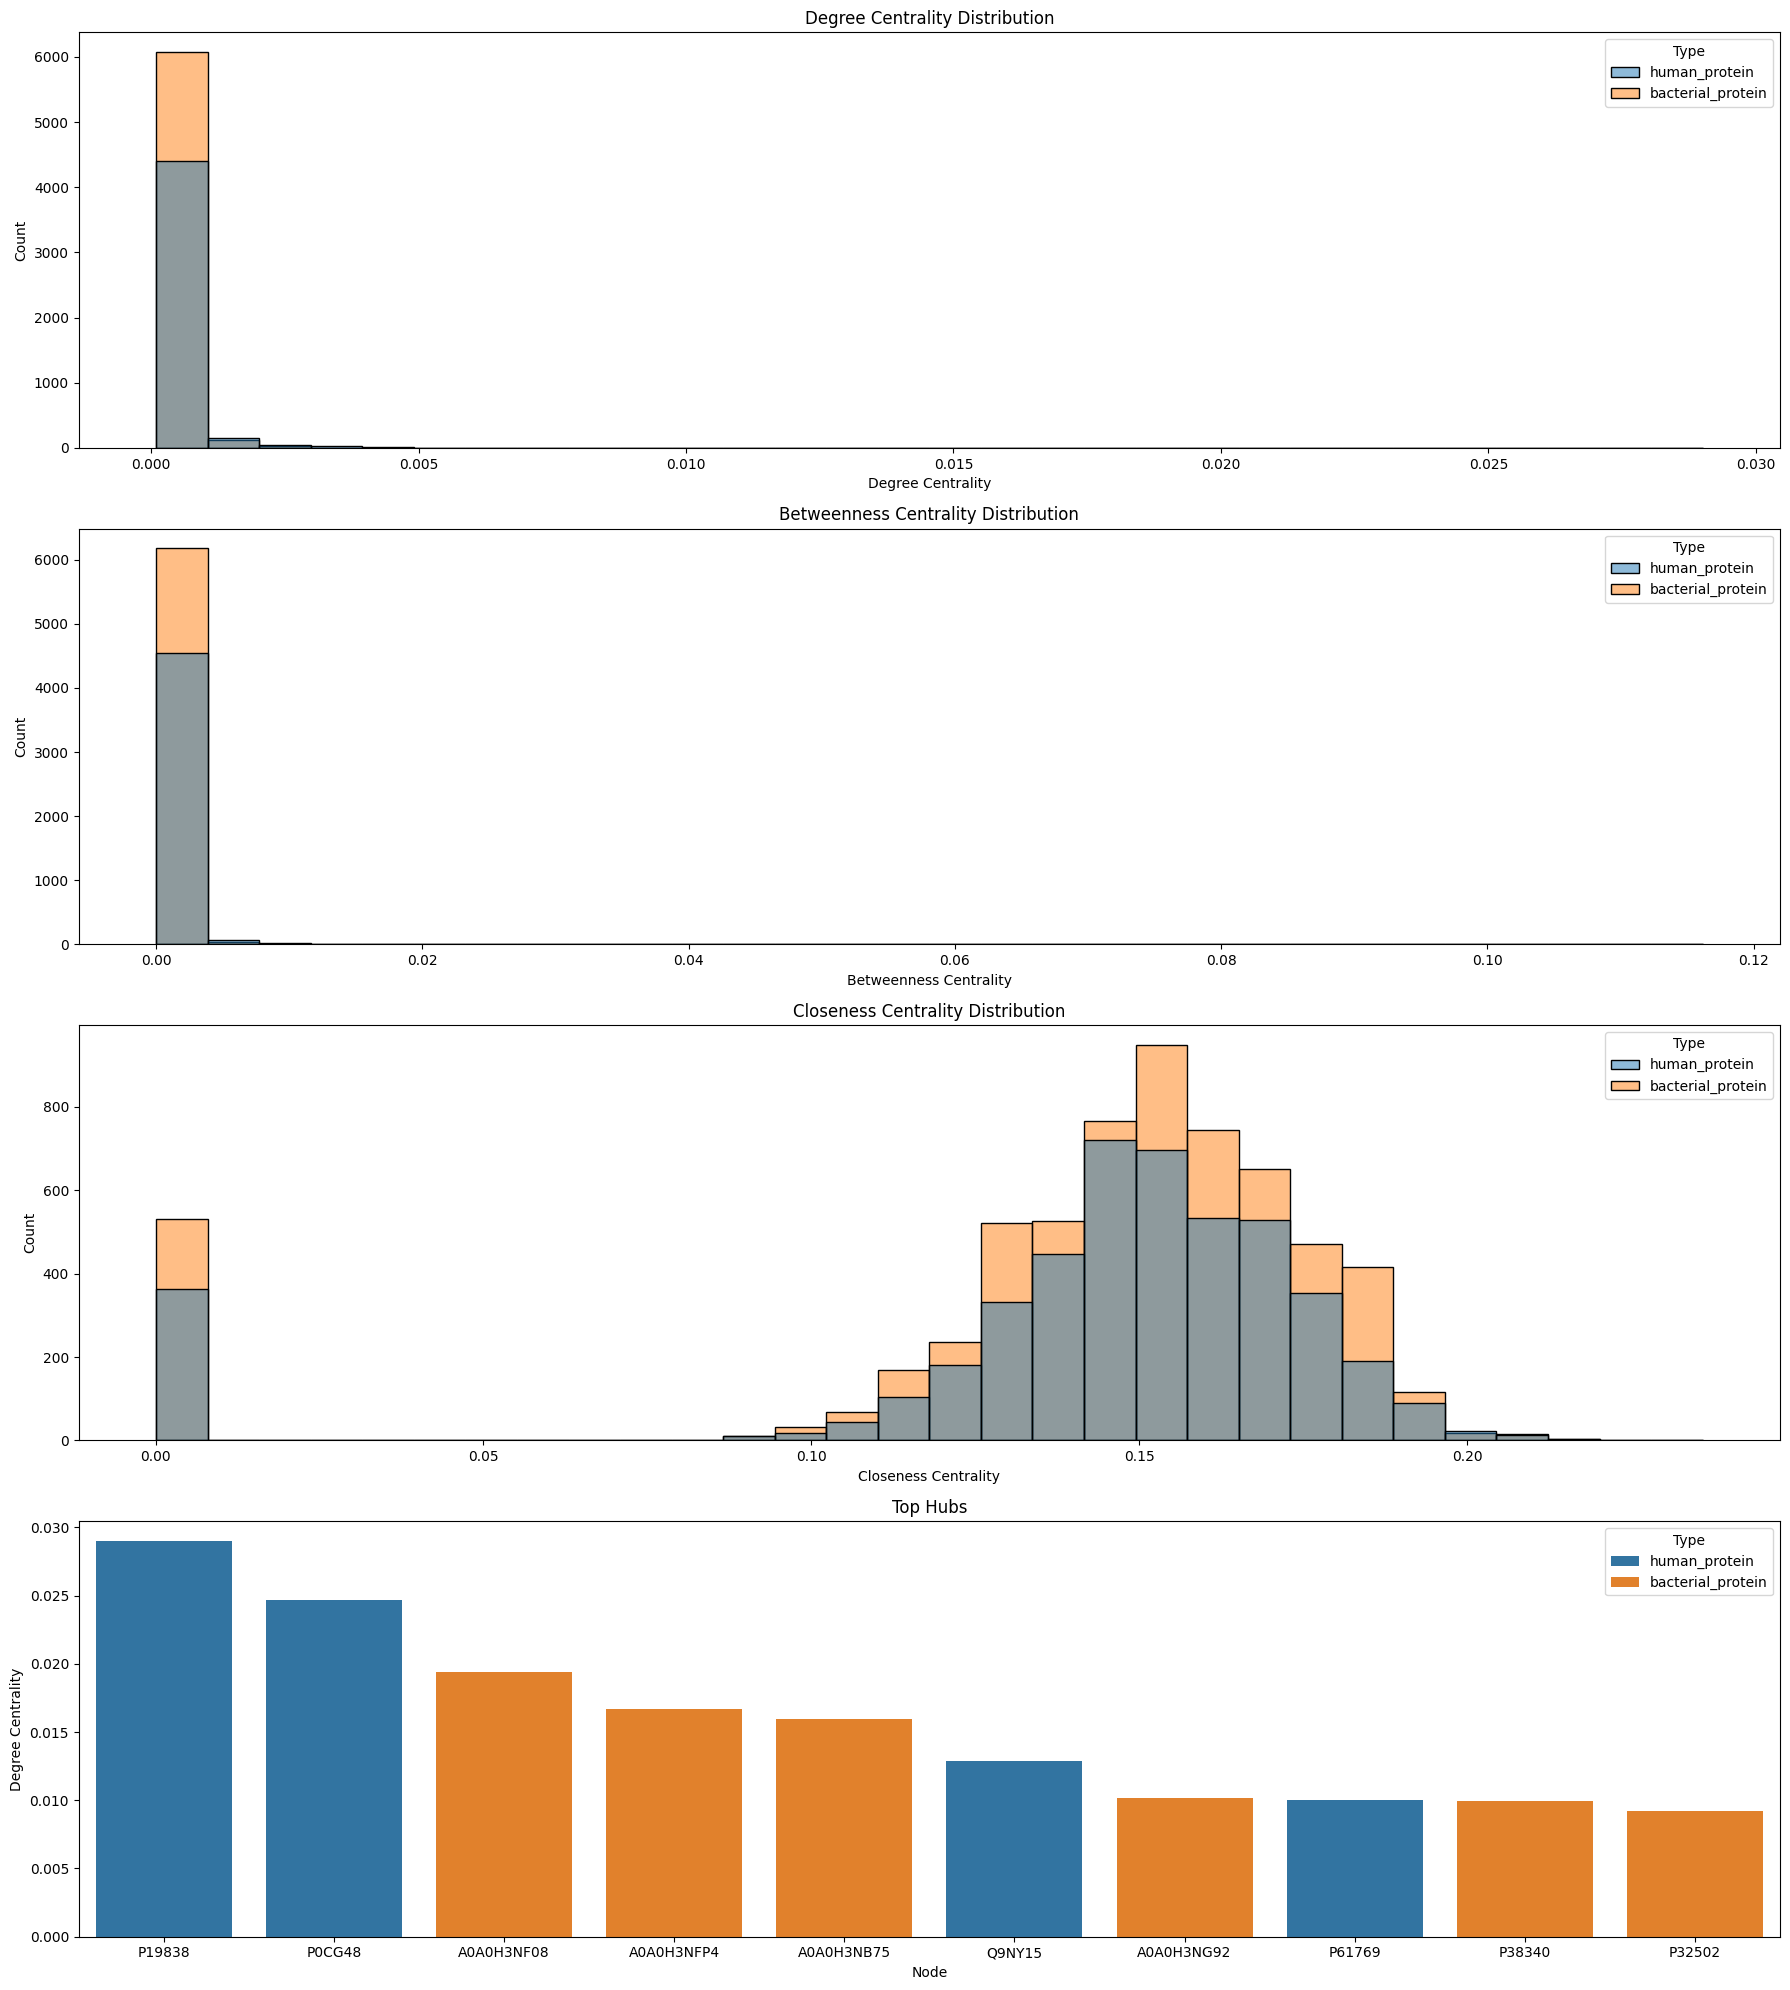

In [42]:
fig, axes = plt.subplots(4, 1, figsize=(18, 20))

# 1. Degree distribution
sns.histplot(data=centrality_df, x="Degree Centrality", hue="Type", ax=axes[0], bins=30, kde=False)
axes[0].set_title("Degree Centrality Distribution")

# 2. Betweenness centrality distribution
sns.histplot(data=centrality_df, x="Betweenness Centrality", hue="Type", ax=axes[1], bins=30, kde=False)
axes[1].set_title("Betweenness Centrality Distribution")

# 3. Closeness centrality distribution
sns.histplot(data=centrality_df, x="Closeness Centrality", hue="Type", ax=axes[2], bins=30, kde=False)
axes[2].set_title("Closeness Centrality Distribution")

#4. Top Hubs
top_hubs = centrality_df.head(10)
sns.barplot(data=top_hubs, x="Node", y="Degree Centrality", hue="Type", ax=axes[3])
axes[3].set_title("Top Hubs")

plt.tight_layout()
plt.show()